# NB02 — Wins Matrix en Coverage-analyse

**Input:** `data/processed/comparisons.csv` — een rij per (respondent x taak) vergelijking  
**Output:**
- `data/processed/wins_matrix.csv` — n x n matrix, W[i][j] = keer dat kruispunt i van j won
- `data/processed/comparison_counts.csv` — vergelijkings- en wintelling per kruispunt
- `data/processed/intersection_index.csv` — kruispunt-ID <-> integer index (nodig voor NB03)

**Doel:** Bouw de wins-matrix die als input dient voor het Bradley-Terry model, en analyseer hoe
gelijkmatig de vergelijkingen verdeeld zijn over de kruispunten. Controleer ook of de
vergelijkingsgraph verbonden is — dat is een vereiste voor een unieke BT-oplossing.

## Stap 1 — Data laden en kruispunt-index bouwen

Laad de vergelijkingstabel en maak een gesorteerde lijst van alle unieke kruispunt-ID's.
De volgorde in deze lijst bepaalt de rij/kolom-indices in de wins-matrix, en wordt later
ook door `choix` (NB03) gebruikt.

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path("..")
PROC_DIR = BASE_DIR / "data" / "processed"

comparisons_df = pd.read_csv(
    PROC_DIR / "comparisons.csv",
    dtype={"intersection_a": str, "intersection_b": str, "winner": str, "loser": str}
)

# Gesorteerde lijst van alle unieke kruispunten (bepaalt vaste index-volgorde)
all_ids   = sorted(set(comparisons_df["intersection_a"]).union(comparisons_df["intersection_b"]))
n         = len(all_ids)
id_to_idx = {iid: i for i, iid in enumerate(all_ids)}

print(f"Vergelijkingen geladen: {len(comparisons_df)}")
print(f"Unieke kruispunten:     {n}")

Vergelijkingen geladen: 216
Unieke kruispunten:     68


## Stap 2 — Wins-matrix opbouwen

Vul een n x n matrix W zodat `W[i][j]` het aantal keer is dat kruispunt `i` van kruispunt `j` won.
Deze matrix vat alle vergelijkingen samen in een compacte structuur die directe toegang geeft
tot het aantal gewonnen duels per paar.

In [3]:
W = np.zeros((n, n), dtype=int)

for _, row in comparisons_df.iterrows():
    i = id_to_idx[row["winner"]]
    j = id_to_idx[row["loser"]]
    W[i, j] += 1

wins_matrix_df = pd.DataFrame(W, index=all_ids, columns=all_ids)

print(f"Wins-matrix vorm: {wins_matrix_df.shape}")
print(f"Totaal vergelijkingen gecodeerd: {W.sum()}  (moet {len(comparisons_df)} zijn)")

Wins-matrix vorm: (68, 68)
Totaal vergelijkingen gecodeerd: 216  (moet 216 zijn)


## Stap 3 — Coverage-statistieken per kruispunt

Bereken voor elk kruispunt hoeveel keer het verscheen in een vergelijking en hoeveel keer het won.
Kruispunten met weinig vergelijkingen (sparse nodes) krijgen minder betrouwbare BT-scores.
Dit geeft ook inzicht in de verdeling van de taaksets.

In [4]:
win_counts  = comparisons_df["winner"].value_counts().rename("n_wins")
loss_counts = comparisons_df["loser"].value_counts().rename("n_losses")

# Tel totaal verschijningen als alternatief 1 of 2
appearances_a = comparisons_df["intersection_a"].value_counts()
appearances_b = comparisons_df["intersection_b"].value_counts()
total_appearances = appearances_a.add(appearances_b, fill_value=0).rename("n_comparisons").astype(int)

counts_df = pd.DataFrame({"intersection_id": all_ids}).set_index("intersection_id")
counts_df = counts_df.join(total_appearances).join(win_counts).join(loss_counts).fillna(0).astype(int)
counts_df["win_rate"] = counts_df["n_wins"] / counts_df["n_comparisons"]

print(counts_df.describe())
print(f"\nKruispunten met 0 vergelijkingen:     {(counts_df['n_comparisons'] == 0).sum()}")
print(f"Sparse (< 5 vergelijkingen):           {(counts_df['n_comparisons'] < 5).sum()}")

       n_comparisons     n_wins   n_losses   win_rate
count      68.000000  68.000000  68.000000  68.000000
mean        6.352941   3.176471   3.176471   0.553189
std         7.506743   4.874365   5.078316   0.414759
min         2.000000   0.000000   0.000000   0.000000
25%         2.000000   1.000000   0.000000   0.118506
50%         4.000000   2.000000   1.000000   0.750000
75%         6.000000   4.000000   4.000000   1.000000
max        36.000000  35.000000  24.000000   1.000000

Kruispunten met 0 vergelijkingen:     0
Sparse (< 5 vergelijkingen):           50


## Stap 4 — Connectiviteit van de vergelijkingsgraph

Het Bradley-Terry model heeft een unieke oplossing als en alleen als de vergelijkingsgraph
zwak verbonden is (weakly connected). We modelleren de vergelijkingen als een gerichte graaf
en controleren dit met NetworkX.

Sterke verbondenheid (strongly connected) is een bonus maar niet strikt vereist.

In [5]:
G = nx.DiGraph()
G.add_nodes_from(all_ids)

for _, row in comparisons_df.iterrows():
    G.add_edge(row["winner"], row["loser"])

weakly_connected   = nx.is_weakly_connected(G)
strongly_connected = nx.is_strongly_connected(G)

print(f"Graph knopen:                {G.number_of_nodes()}")
print(f"Graph kanten (uniek):        {G.number_of_edges()}")
print(f"Zwak verbonden:              {weakly_connected}  <- vereist voor unieke BT-oplossing")
print(f"Sterk verbonden:             {strongly_connected}")

if not weakly_connected:
    components = list(nx.weakly_connected_components(G))
    print(f"WAARSCHUWING: {len(components)} zwak verbonden componenten gevonden!")
    for i, comp in enumerate(components):
        print(f"  Component {i}: {len(comp)} knopen")

Graph knopen:                68
Graph kanten (uniek):        84
Zwak verbonden:              False  <- vereist voor unieke BT-oplossing
Sterk verbonden:             False
WAARSCHUWING: 7 zwak verbonden componenten gevonden!
  Component 0: 46 knopen
  Component 1: 2 knopen
  Component 2: 2 knopen
  Component 3: 7 knopen
  Component 4: 6 knopen
  Component 5: 3 knopen
  Component 6: 2 knopen


## Stap 5 — Verdeling van vergelijkingen visualiseren

Twee histogrammen: hoeveel vergelijkingen elk kruispunt had, en de winratio-verdeling.
Een scheef histogram links wijst op ongelijke coverage; een brede verdeling rechts is normaal
(sommige kruispunten zijn duidelijk gevaarlijker dan andere).

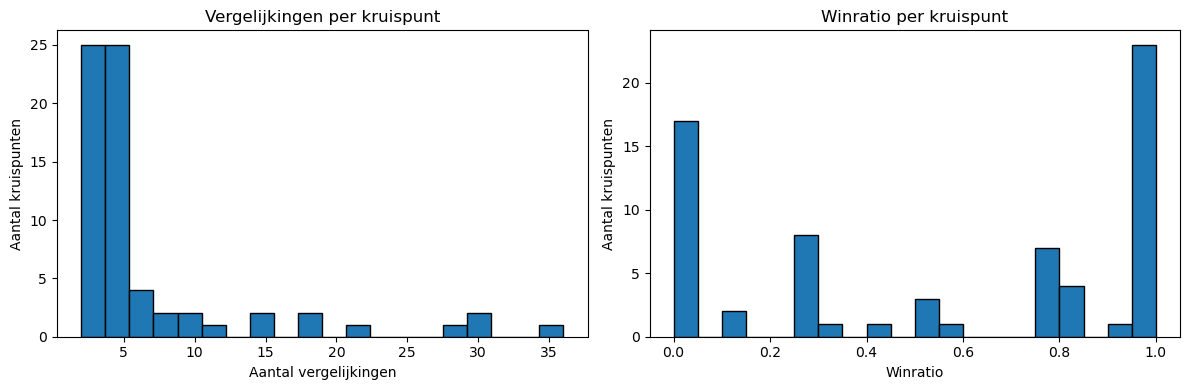

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(counts_df["n_comparisons"], bins=20, edgecolor="black")
axes[0].set_title("Vergelijkingen per kruispunt")
axes[0].set_xlabel("Aantal vergelijkingen")
axes[0].set_ylabel("Aantal kruispunten")

axes[1].hist(counts_df["win_rate"].dropna(), bins=20, edgecolor="black")
axes[1].set_title("Winratio per kruispunt")
axes[1].set_xlabel("Winratio")
axes[1].set_ylabel("Aantal kruispunten")

plt.tight_layout()
plt.savefig(PROC_DIR / "coverage_distributions.png", dpi=120)
plt.show()

## Stap 6 — Opslaan

Sla de wins-matrix, de coverage-tellingen, en de kruispunt-index op.
De index-tabel (`intersection_index.csv`) is nodig in NB03 om de `choix`-integer-indices
terug te vertalen naar kruispunt-ID's.

In [7]:
wins_matrix_df.to_csv(PROC_DIR / "wins_matrix.csv")
counts_df.reset_index().to_csv(PROC_DIR / "comparison_counts.csv", index=False)

# Sla de vaste index-volgorde op zodat NB03 en NB05 dezelfde mapping gebruiken
index_df = pd.DataFrame({"intersection_id": all_ids, "index": range(n)})
index_df.to_csv(PROC_DIR / "intersection_index.csv", index=False)

print(f"wins_matrix.csv opgeslagen ({n}x{n})")
print(f"comparison_counts.csv opgeslagen ({n} rijen)")
print(f"intersection_index.csv opgeslagen ({n} rijen)")

wins_matrix.csv opgeslagen (68x68)
comparison_counts.csv opgeslagen (68 rijen)
intersection_index.csv opgeslagen (68 rijen)
